In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [15]:
import requests
import io 

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

response = requests.get(URL)

response.raise_for_status()

csv_content = io.StringIO(response.text)

df = pd.read_csv(csv_content)

In [19]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [25]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

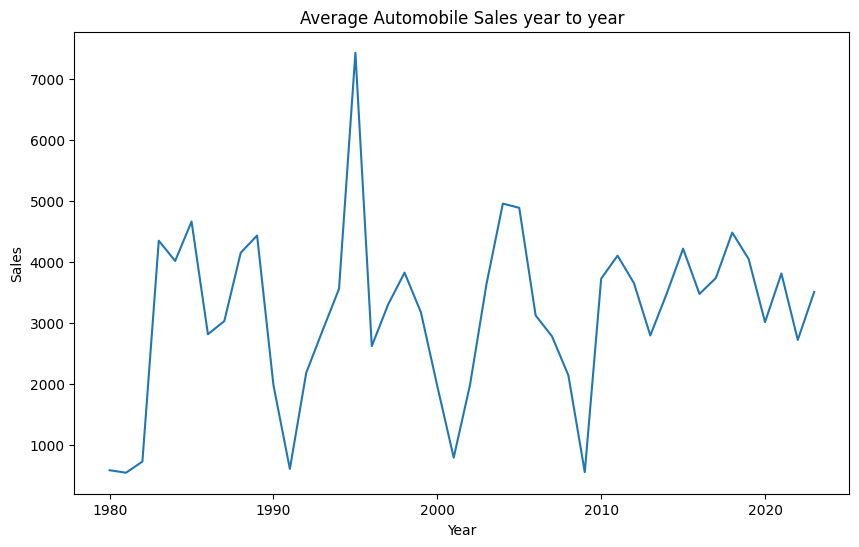

In [31]:
import matplotlib.pyplot as plt 

df_year = df.groupby(df["Year"])["Automobile_Sales"].mean()

plt.figure(figsize = (10,6))

df_year.plot(kind = "line" , x = "Year" , y = "Automobile_Sales")
plt.title("Average Automobile Sales year to year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

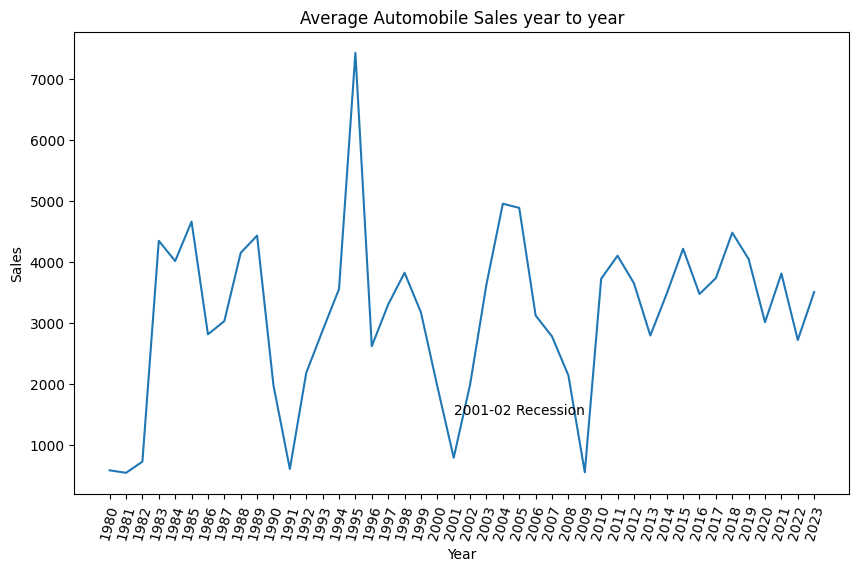

In [37]:
import matplotlib.pyplot as plt 

df_year = df.groupby(df["Year"])["Automobile_Sales"].mean()

plt.figure(figsize = (10,6))

df_year.plot(kind = "line" , x = "Year" , y = "Automobile_Sales")
plt.xticks(list(range(1980,2024)) , rotation = 75)
plt.title("Average Automobile Sales year to year")
plt.text(2001 , 1500 , "2001-02 Recession")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

<Figure size 1000x600 with 0 Axes>

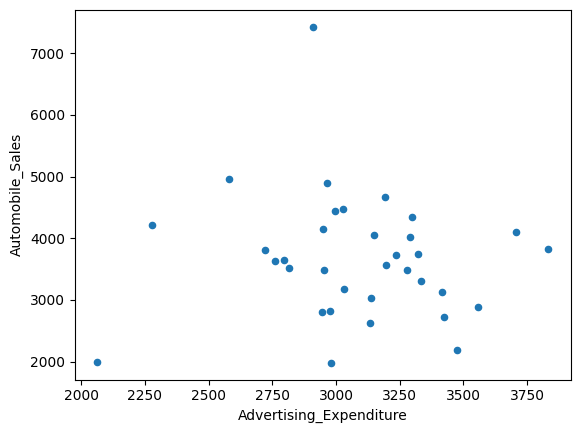

In [43]:
df_res_group = df[df['Recession']==0].groupby('Year')[['Advertising_Expenditure', 'Automobile_Sales']].mean().reset_index()

plt.figure(figsize = (10,6))
df_res_group.plot(kind = "scatter" , x = "Advertising_Expenditure" , y = "Automobile_Sales")
plt.show()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

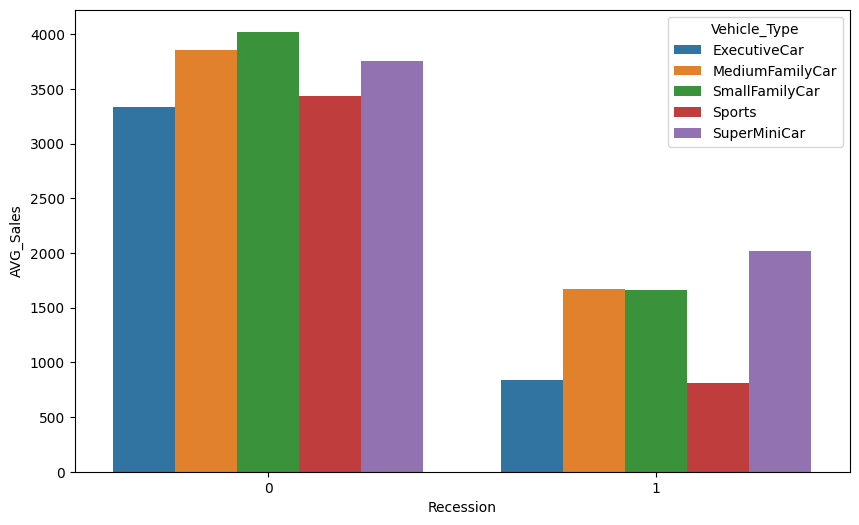

In [89]:
df_type = df.groupby(["Recession", "Vehicle_Type"] , as_index = False).agg(
    AVG_Sales = ('Automobile_Sales', 'mean')
)
plt.figure(figsize = (10,6))

sns.barplot(x = "Recession"  , y ="AVG_Sales"  , hue = "Vehicle_Type" , data = df_type)
plt.show()


In [91]:
df_type.head(20)

,Recession,Vehicle_Type,AVG_Sales
0,0,ExecutiveCar,3332.337025
1,0,MediumFamilyCar,3853.390815
2,0,SmallFamilyCar,4021.915255
3,0,Sports,3431.048093
4,0,SuperMiniCar,3754.276120
5,1,ExecutiveCar,842.056200
6,1,MediumFamilyCar,1672.964086
7,1,SmallFamilyCar,1662.741250
8,1,Sports,814.776429
9,1,SuperMiniCar,2019.327126
